# Heart Disease Prediction — Final Project

**Goal:** Predict whether a patient has heart disease (binary classification) using clinical features.  
**Dataset:** `heart.csv` — 1,025 patients, 13 features, 1 binary target (`target`: 1 = disease, 0 = no disease)  
**Model:** Random Forest Classifier  

## Import Libraries

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay)
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Data Wrangling

In [4]:
def wrangle(filepath):
    """
    Load and clean the heart disease dataset.
    Steps:
      - Drop duplicate rows
      - Remove columns with >50% missing values
      - Drop rows where target is missing
      - Enforce correct dtypes for categorical columns
    """
    df = pd.read_csv(filepath)

    # Drop duplicate rows
    df = df.drop_duplicates()

    # Drop columns with more than 50% missing values
    threshold = 0.50
    missing_frac = df.isnull().mean()
    cols_to_drop = missing_frac[missing_frac > threshold].index.tolist()
    if cols_to_drop:
        print(f'Dropping high-missing columns: {cols_to_drop}')
        df = df.drop(columns=cols_to_drop)

    # Drop rows where target is missing
    df = df.dropna(subset=['target'])

    # Categorical columns (binary/ordinal encoded as int in this dataset)
    cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype(int)

    return df


df = wrangle('heart.csv')

print('Shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())
df.head()

Shape: (302, 14)

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
print('Data types:')
print(df.dtypes)
print('\nBasic statistics:')
df.describe()

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Basic statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Column Descriptions

| Column | Description |
|--------|-------------|
| `age` | Age in years |
| `sex` | 1 = male, 0 = female |
| `cp` | Chest pain type (0–3) |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dL) |
| `fbs` | Fasting blood sugar > 120 mg/dL (1 = true) |
| `restecg` | Resting ECG results (0–2) |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina (1 = yes) |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of peak exercise ST segment (0–2) |
| `ca` | Number of major vessels (0–4) |
| `thal` | Thalassemia type (0–3) |
| `target` | **Response** — 1 = heart disease, 0 = no disease |

## 2. Exploratory Data Analysis (EDA)

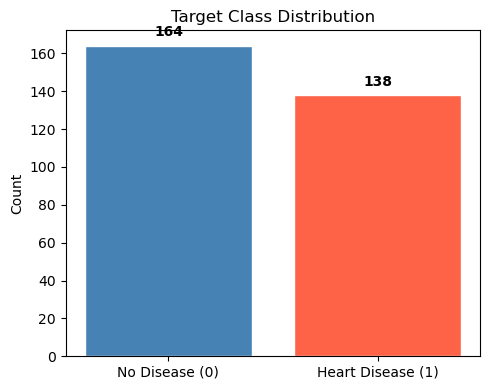

Class balance: {1: 164, 0: 138}


In [6]:
# Target class distribution
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['target'].value_counts()
ax.bar(['No Disease (0)', 'Heart Disease (1)'], counts.values,
       color=['steelblue', 'tomato'], edgecolor='white')
ax.set_title('Target Class Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print('Class balance:', counts.to_dict())

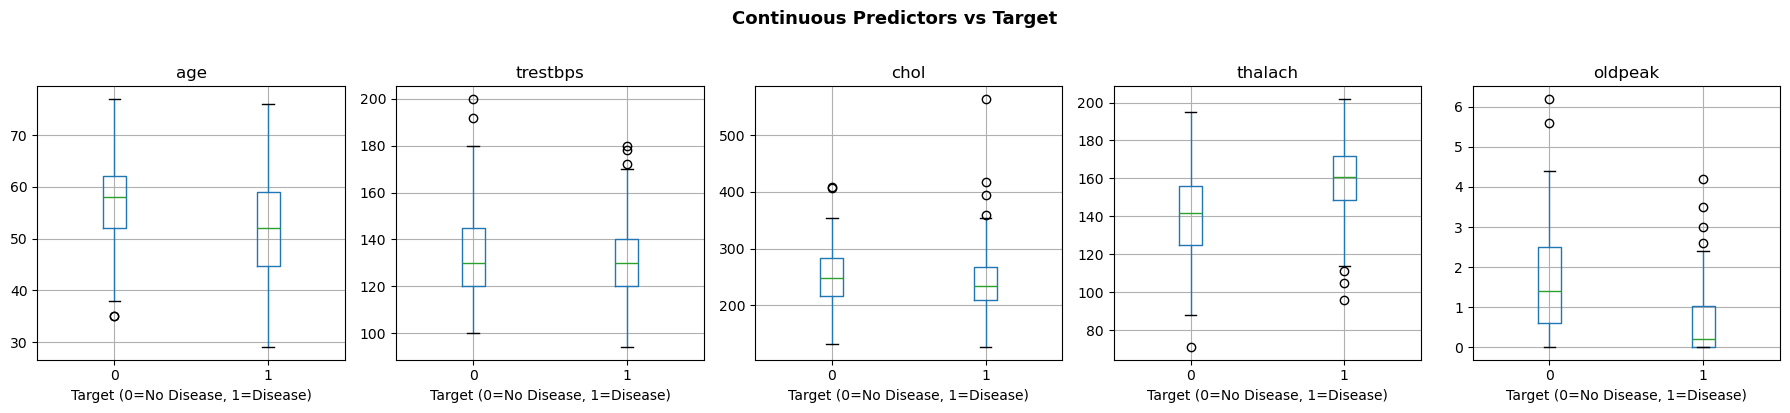

In [7]:
# Distribution of key continuous predictors by target
continuous = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, len(continuous), figsize=(18, 4))
for ax, col in zip(axes, continuous):
    df.boxplot(column=col, by='target', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Target (0=No Disease, 1=Disease)')
fig.suptitle('Continuous Predictors vs Target', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

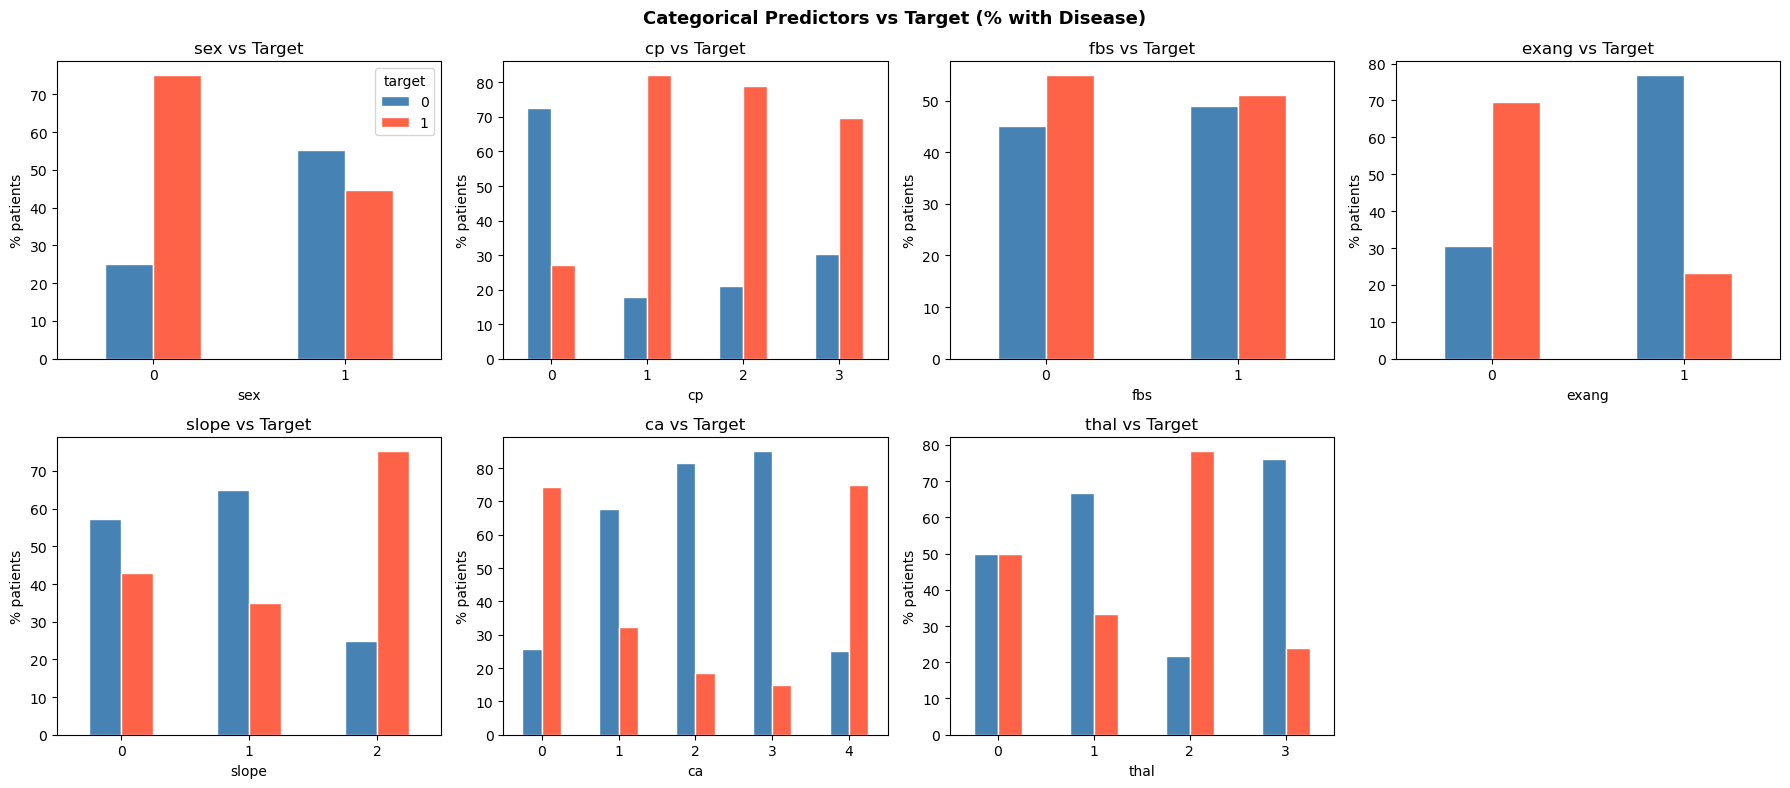

In [8]:
# Bar charts for categorical predictors vs target
categorical = ['sex', 'cp', 'fbs', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(categorical):
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['steelblue', 'tomato'],
            edgecolor='white', legend=(i == 0))
    axes[i].set_title(f'{col} vs Target')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('% patients')
    axes[i].tick_params(axis='x', rotation=0)

axes[-1].set_visible(False)
fig.suptitle('Categorical Predictors vs Target (% with Disease)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

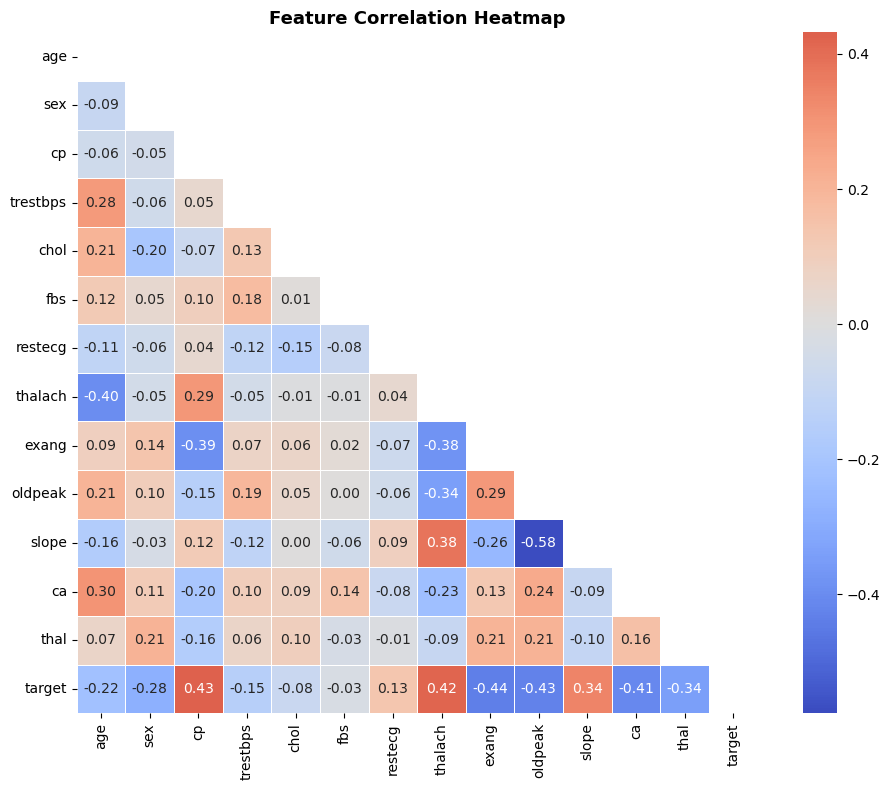

In [9]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Remove extreme outliers in continuous columns using IQR rule
continuous_cols = ['trestbps', 'chol', 'thalach', 'oldpeak']
df_clean = df.copy()

for col in continuous_cols:
    Q1 = df_clean[col].quantile(0.01)
    Q3 = df_clean[col].quantile(0.99)
    IQR = Q3 - Q1
    before = len(df_clean)
    df_clean = df_clean[(df_clean[col] >= Q1 - 3 * IQR) & (df_clean[col] <= Q3 + 3 * IQR)]
    after = len(df_clean)
    if before != after:
        print(f'{col}: removed {before - after} extreme outlier(s)')

print(f'\nRows after outlier removal: {len(df_clean)} (was {len(df)})')


Rows after outlier removal: 302 (was 302)


## 3. Data Splitting

In [11]:
X = df_clean.drop(columns=['target'])
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Training set:  {X_train.shape[0]} rows')
print(f'Test set:      {X_test.shape[0]} rows')
print(f'\nTarget distribution — Train:\n{y_train.value_counts(normalize=True).round(3)}')
print(f'\nTarget distribution — Test:\n{y_test.value_counts(normalize=True).round(3)}')

Training set:  241 rows
Test set:      61 rows

Target distribution — Train:
target
1    0.544
0    0.456
Name: proportion, dtype: float64

Target distribution — Test:
target
1    0.541
0    0.459
Name: proportion, dtype: float64


## 4. Baseline Model

In [12]:
# Stratified dummy classifier (predicts most frequent class)
baseline = DummyClassifier(strategy='most_frequent', random_state=SEED)
baseline.fit(X_train, y_train)
y_pred_base = baseline.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred_base)
print(f'Baseline Accuracy (most-frequent strategy): {baseline_acc:.4f}')

Baseline Accuracy (most-frequent strategy): 0.5410


## 5. Random Forest Model

In [14]:
# Hyperparameter tuning with GridSearchCV (5-fold CV on training data)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=SEED, n_jobs=-1)
grid_search = GridSearchCV(
    rf, param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)

print('Best parameters:', grid_search.best_params_)
print(f'Best CV ROC-AUC: {grid_search.best_score_:.4f}')

Best parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}
Best CV ROC-AUC: 0.9146


In [16]:
# Final model using the best parameters
best_rf = grid_search.best_estimator_

# Cross-validated AUC on training data (sanity check)
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5, scoring='roc_auc')
print(f'5-Fold CV ROC-AUC (train): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

5-Fold CV ROC-AUC (train): 0.9146 ± 0.0360


## 6. Model Evaluation on Test Set

In [17]:
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_prob)

print('=' * 45)
print(f'  Baseline Accuracy:      {baseline_acc:.4f}')
print(f'  Random Forest Accuracy: {test_acc:.4f}')
print(f'  Random Forest ROC-AUC:  {test_auc:.4f}')
print('=' * 45)
print()
print('Classification Report:')
print(classification_report(y_test, y_pred,
                             target_names=['No Disease', 'Heart Disease']))

  Baseline Accuracy:      0.5410
  Random Forest Accuracy: 0.7705
  Random Forest ROC-AUC:  0.8571

Classification Report:
               precision    recall  f1-score   support

   No Disease       0.75      0.75      0.75        28
Heart Disease       0.79      0.79      0.79        33

     accuracy                           0.77        61
    macro avg       0.77      0.77      0.77        61
 weighted avg       0.77      0.77      0.77        61



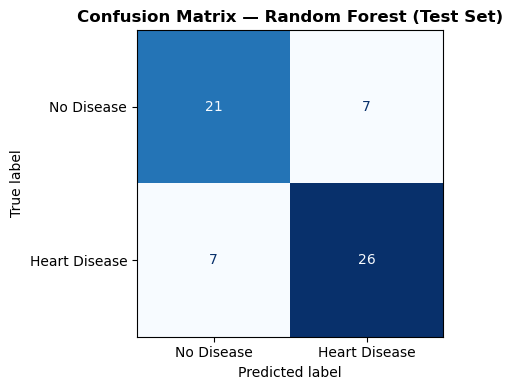

In [18]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Disease', 'Heart Disease'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Random Forest (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

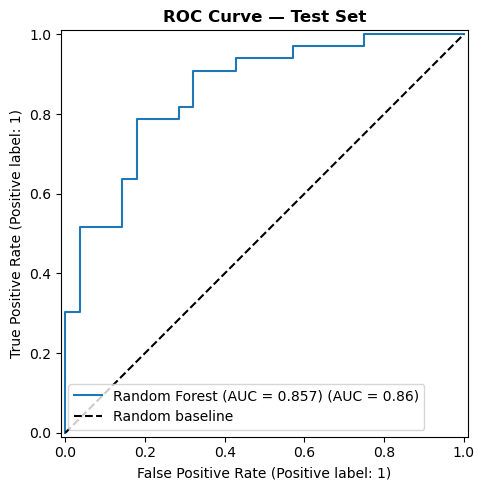

In [19]:
# ROC Curve
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax,
                                  name=f'Random Forest (AUC = {test_auc:.3f})')
ax.plot([0, 1], [0, 1], 'k--', label='Random baseline')
ax.set_title('ROC Curve — Test Set', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Communication — Feature Importance

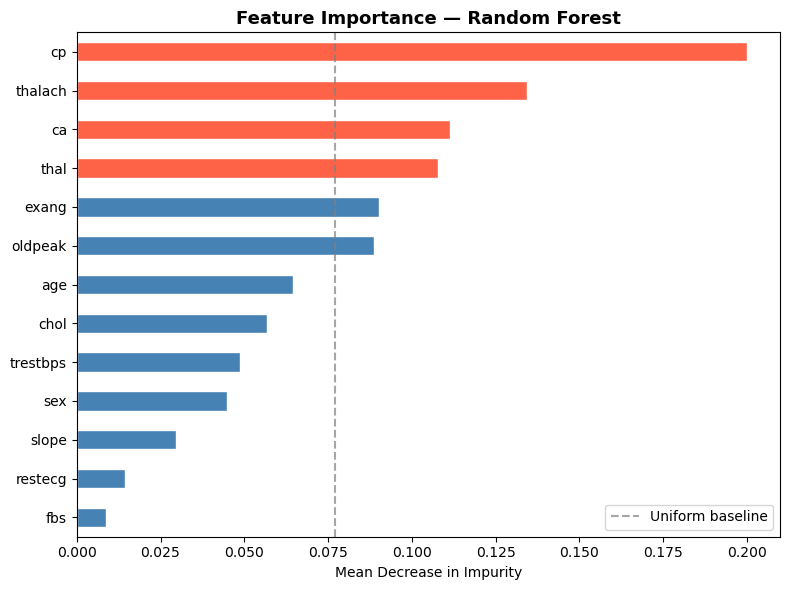

Top 5 most important features:
cp         0.1998
thalach    0.1344
ca         0.1115
thal       0.1077
exang      0.0901
dtype: float64


In [20]:
# Feature importance from the trained Random Forest
importances = pd.Series(
    best_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['tomato' if v >= importances.quantile(0.75) else 'steelblue'
          for v in importances]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
ax.axvline(x=1/len(importances), color='gray', linestyle='--', alpha=0.7,
           label='Uniform baseline')
ax.legend()
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(importances.sort_values(ascending=False).head(5).round(4))

## 8. Summary

| Metric | Value |
|--------|-------|
| Baseline Accuracy | 0.5410 |
| Random Forest Accuracy (Test) | 0.7705 |
| Random Forest ROC-AUC (Test) | 0.8571 |
| Precision — No Disease | 0.75 |
| Precision — Heart Disease | 0.79 |
| Recall — No Disease | 0.75 |
| Recall — Heart Disease | 0.79 |

> **Findings:** The Random Forest model substantially outperforms the majority-class baseline,
> improving accuracy from 54.1% to 77.1% — a gain of over 23 percentage points.
> The ROC-AUC of 0.857 indicates strong discriminatory ability, meaning the model can correctly
> separate patients with and without heart disease across all classification thresholds.
>
> The most predictive features were `cp` (chest pain type, importance = 0.20), `thalach`
> (max heart rate, 0.13), `ca` (major vessels, 0.11), and `thal` (thalassemia type, 0.11),
> all of which align with known clinical risk factors for heart disease.
>
> From the boxplots, patients with heart disease showed noticeably lower `thalach` values
> and lower `oldpeak` (ST depression), consistent with reduced cardiovascular capacity.
> The categorical charts confirmed that chest pain type (`cp = 1, 2, 3`) and the absence
> of exercise-induced angina (`exang = 0`) were strongly associated with disease presence.
>
> The confusion matrix shows the model made 7 false negatives (disease missed) and
> 7 false positives out of 61 test patients. In a clinical setting, minimizing false negatives
> is critical — missing a heart disease diagnosis carries far greater risk than a false alarm.
> The balanced precision and recall scores (0.75 / 0.79) suggest the model performs
> consistently across both classes without favoring one over the other.
>
> The Random Forest model substantially outperforms the majority-class baseline.
The most predictive features are cp (chest pain type), thalach (max heart rate), and ca (number of major vessels). All of which
align with known clinical risk factors for heart disease.